In [2]:
%reload_ext autoreload
%autoreload 2


In [3]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import  Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from flax import nnx

import matplotlib.pyplot as plt

plt.style.use("../dmri/utils/pyloric_black.mplstyle")

# Ignore font warnings from matplotlib
import warnings
warnings.filterwarnings("ignore")
# Ignore missing font warnings from seaborn
warnings.filterwarnings("ignore", module="matplotlib.font_manager")

Duplicate key in file '../dmri/utils/pyloric_black.mplstyle', line 65 ('savefig.facecolor    : black       # Ensures black background when saving')


In [4]:
from dmri.train.utils import load_cfg, load_checkpoint

checkpoint, model, simulator = load_checkpoint("/home/macke/mgloeckler90/dmri/results/full_ball3stick_simformer6")
graphdef, params, static, state = nnx.split(model, nnx.Param, nnx.Intermediate, ...)
params = checkpoint["params_ema"]

model = nnx.merge(graphdef, params, static, state)
model.eval()

In [19]:
sim_type = model.tokenizer.simulator

In [20]:
p_mask,masks, theta, x_os, acq, score = jax.vmap(simulator)(jax.random.split(jax.random.PRNGKey(0), num=200))

[ True  True  True  True  True]
[   0.    0.    0.    0.    0.    0. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000. 1000.
 1000. 1000. 1000. 1000. 1000. 1000. 1000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.]


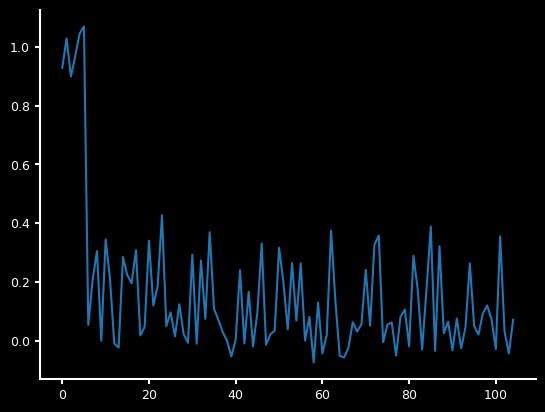

In [51]:
#idx = 2
idx = 31
print(masks[idx])
print(acq.bvals[idx])
plt.plot(x_os[idx])

In [52]:
from functools import partial

In [55]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=64, max_noise=80, model_mask=masks[idx]), in_axes=(0,None,None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals[idx], acq.bvecs[idx], x_os[idx])

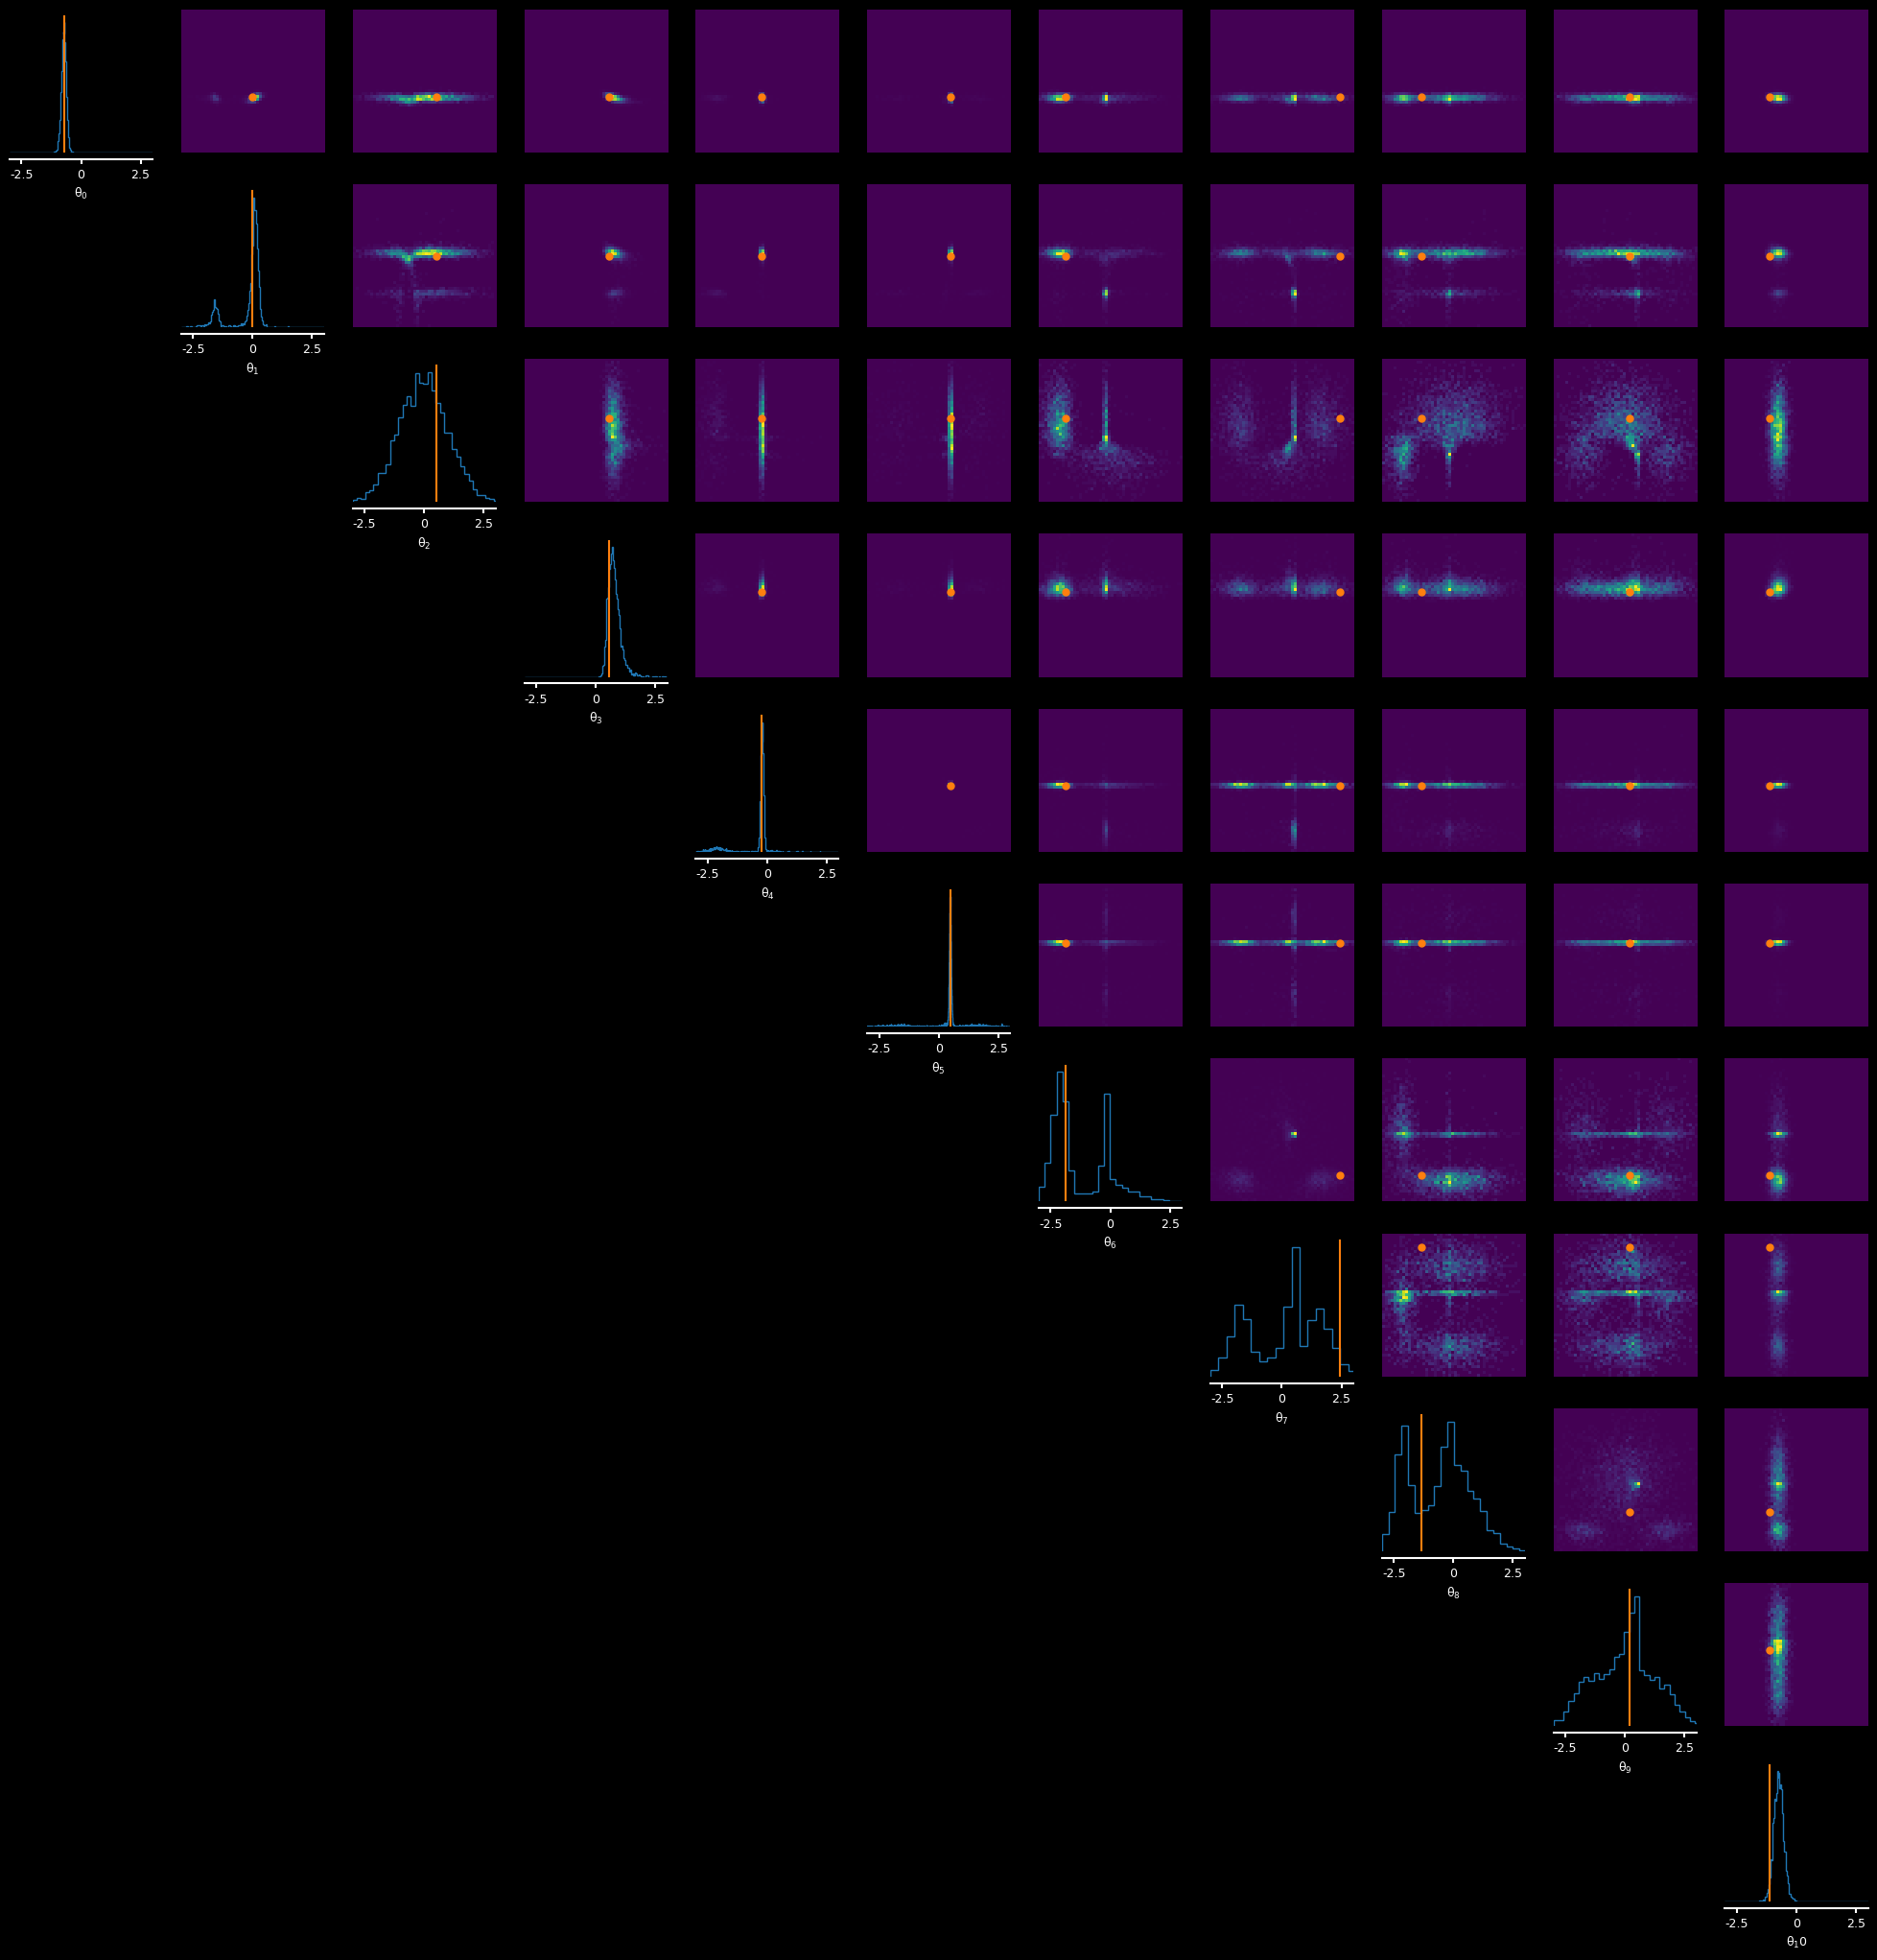

In [56]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, points=[theta[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [57]:
from blackjax import hmc, tempered_smc,mala
from blackjax.smc.resampling import systematic


In [58]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=masks[idx]).signal(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), rng=rng)

def log_likelihood_fn(theta):
    simulator = sim_type.from_theta(theta, model_mask=masks[idx])
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x_os[idx])
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)


In [59]:

@jax.jit
def smc(thetas):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.001, num_integration_steps=10, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic

    smc = tempered_smc(log_prior_fn, log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=0.99)

    def step(state, rng):
        state, i = state
        lmbda = 0.99 + i*0.01/5
        new_state, info = smc.step(rng, state, lmbda)
        ess = 1/jnp.sum(new_state.weights**2)
        acc_rate = info.update_info.acceptance_rate
        jax.debug.print("ESS: {ess}, acc_rate: {acc_rate}", ess=ess, acc_rate=acc_rate.mean())
        return (new_state, i+1), info

    rng_keys = jax.random.split(jax.random.key(0), 5)
    final_state, _ = jax.lax.scan(step, (state, 0), rng_keys)
    return final_state[0].particles


In [60]:
particles =smc(thetas_post)

ESS: 4096.0, acc_rate: 0.999570369720459
ESS: 4095.50244140625, acc_rate: 0.9982167482376099
ESS: 4095.578125, acc_rate: 0.9978657960891724
ESS: 4095.6279296875, acc_rate: 0.9978219866752625
ESS: 4095.65673828125, acc_rate: 0.9978631734848022


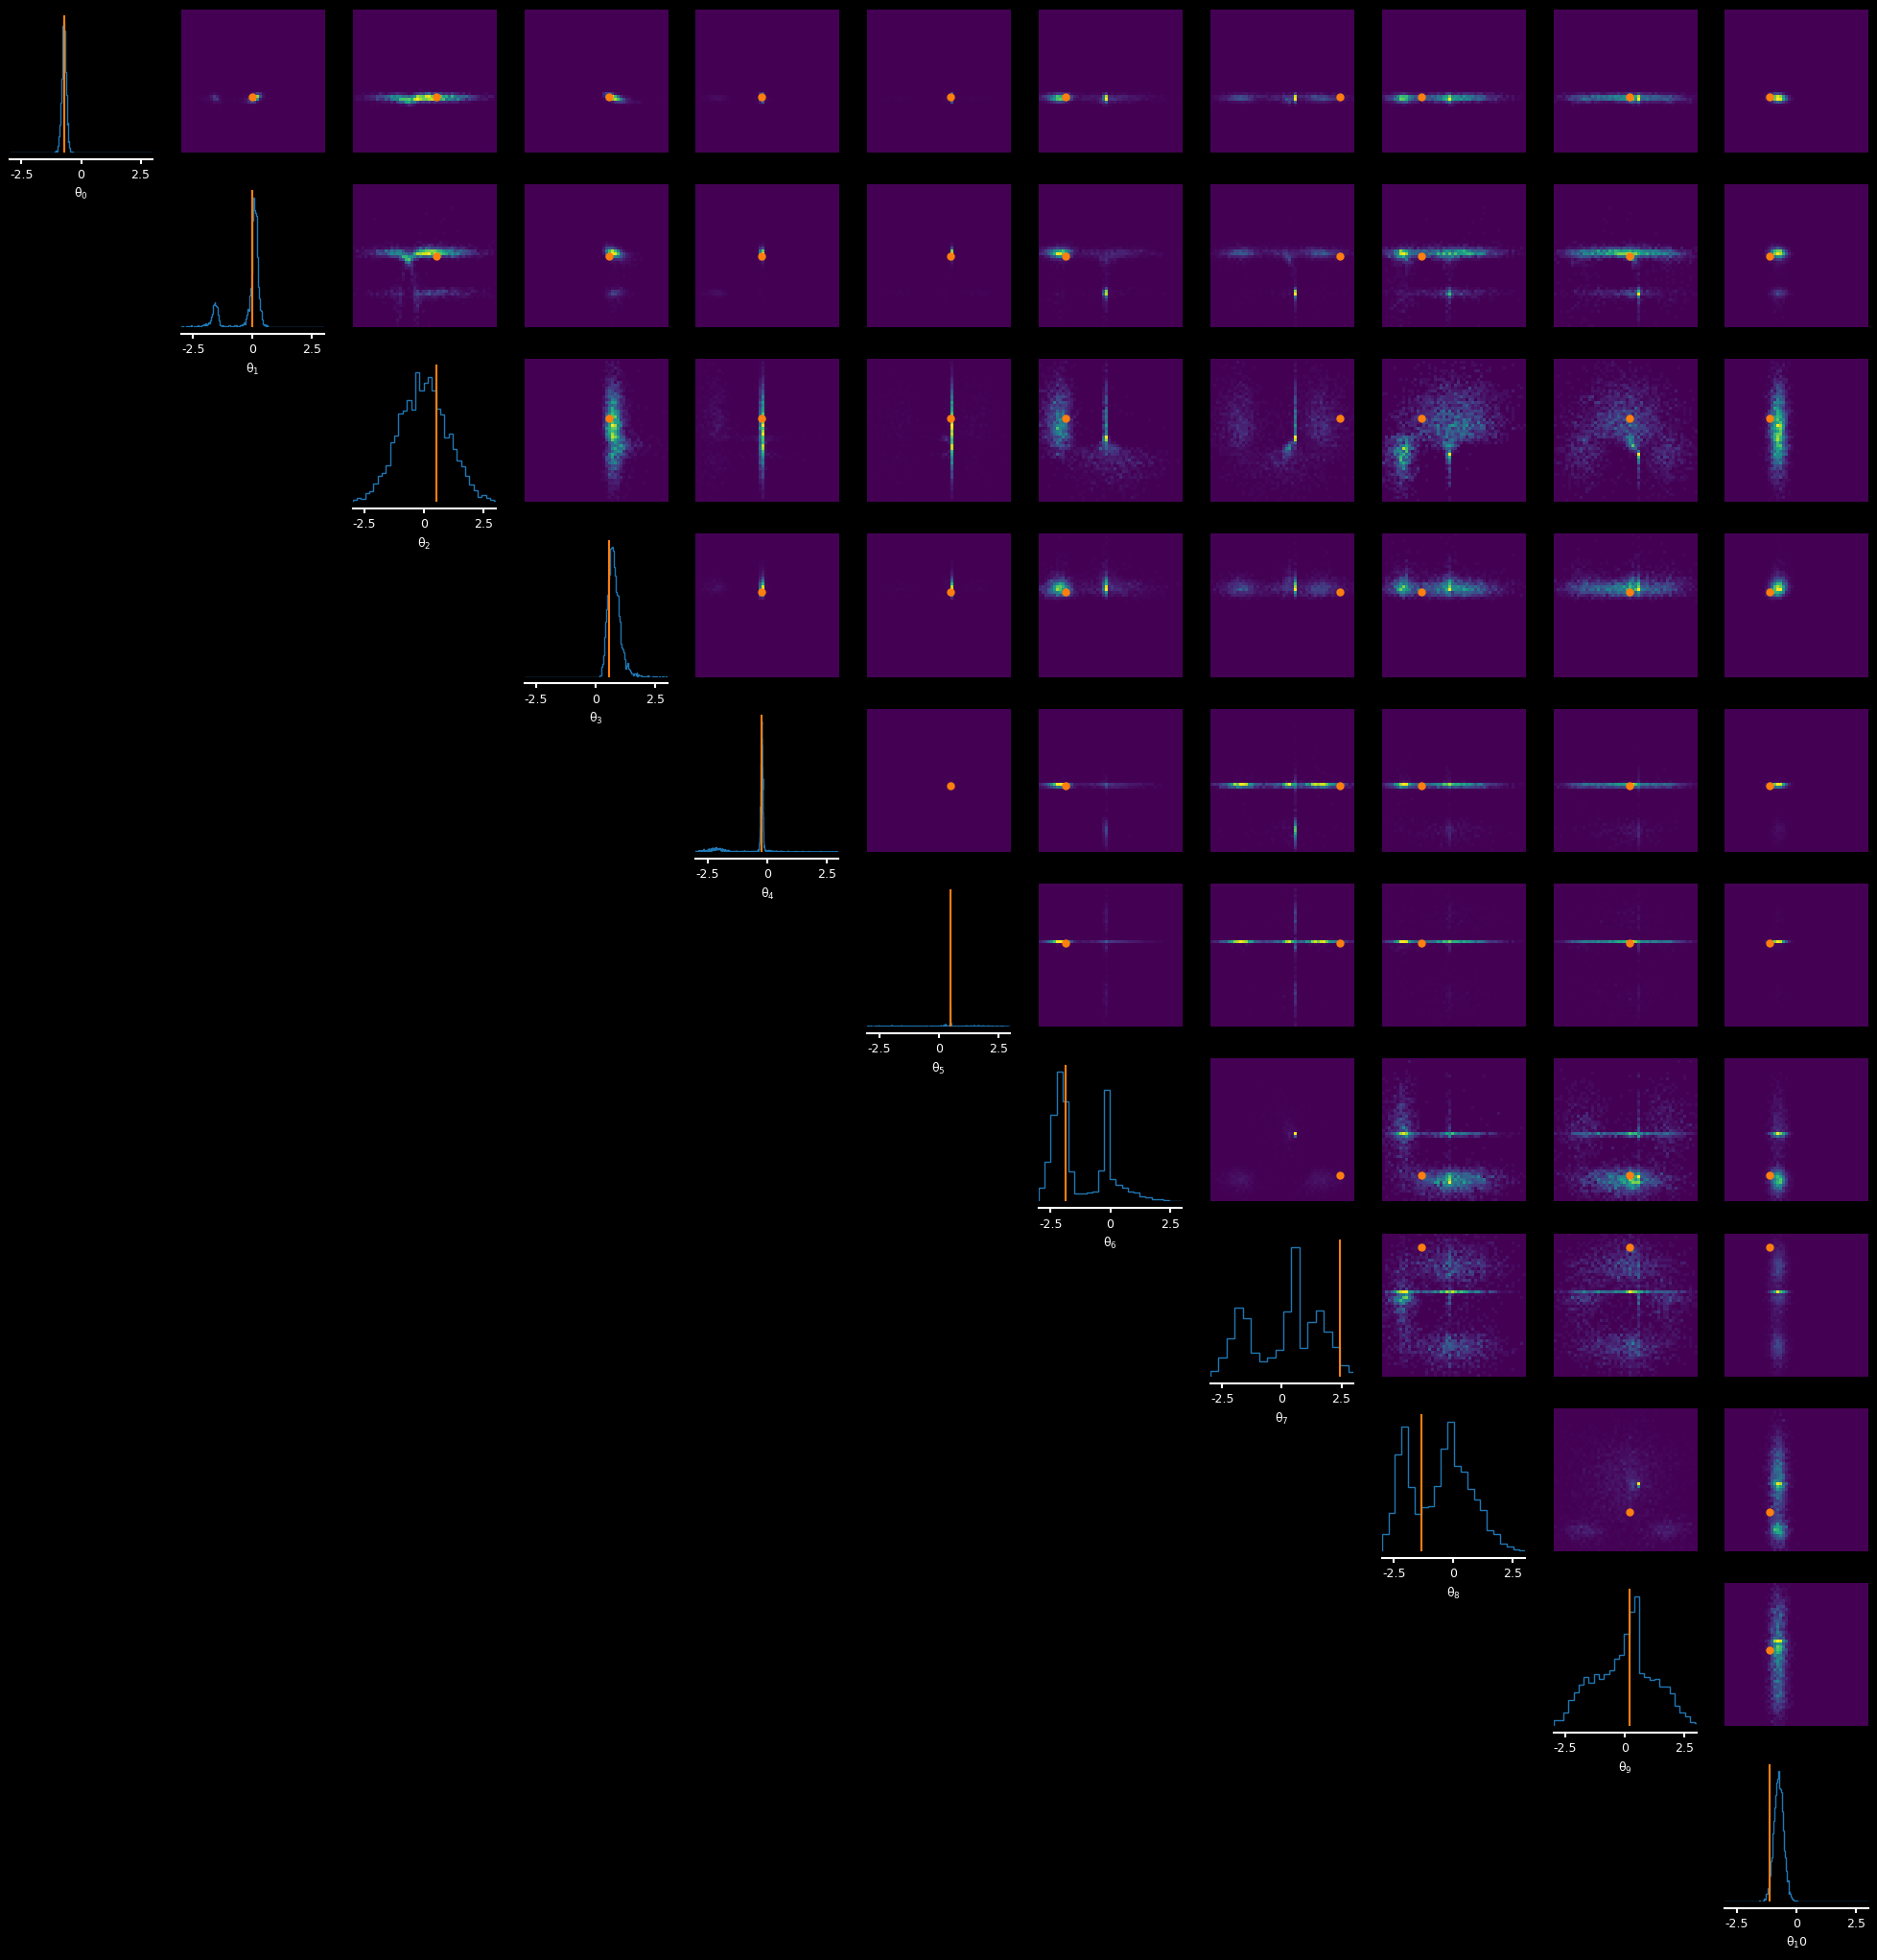

In [61]:
_ = pairplot(particles, points=[theta[idx],], limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

Text(0, 0.5, 'MRI Signal')

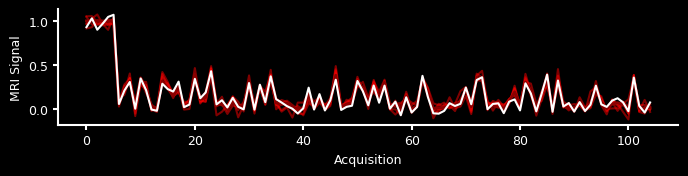

In [64]:

posterior_preds = jax.vmap(posterior_pred)(particles, jax.random.split(jax.random.key(0), 4096))
bvals = acq.bvals[idx]
bvecs = acq.bvecs[idx]
sort_bvals = jnp.argsort(bvals)
bvals = bvals[sort_bvals]
posterior_preds_sorted = posterior_preds[:,sort_bvals]
x_o = x_os[idx][sort_bvals]


fig = plt.figure(figsize=(8, 1.5))

_ = plt.plot(posterior_preds_sorted[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds_sorted.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

# fig.savefig(f"../figures/posterior_pred_idx={idx}.svg")
# fig.savefig(f"../figures/posterior_pred_idx={idx}.png")

In [65]:
def loglikelihood(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_posterior(theta, mask, acq, x):
    theta_mask = model.tokenizer.theta_mask(mask)
    return loglikelihood(theta, mask, acq, x) + (theta_mask*jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)).sum()

def log_q(theta, mask, acq, x):
    return model.log_prob_theta(theta, acq.bvals, acq.bvecs, x, num_steps=512, max_noise=20, model_mask=mask)

@jax.grad
def true_score(theta, mask, acq, x):
    return log_posterior(theta, mask, acq, x).sum()


@jax.jit
def effectve_sample_size(thetas):
    logp = jax.vmap(partial(log_posterior, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    logq = jax.vmap(partial(log_q, mask=masks[idx], acq=acquisition_scheme(acq.bvals[idx], acq.bvecs[idx]), x=x_os[idx]))(thetas)
    log_w = logp - logq
    # Self normalized importance weights
    w = jax.nn.softmax(log_w)
    return 1/jnp.sum(w**2)


In [66]:
effectve_sample_size(thetas_post)

Array(1.001, dtype=float32)

In [119]:
from dipy.data import get_fnames
from dipy.io.gradients import read_bvals_bvecs
from dipy.io.image import load_nifti

import numpy as np

data, affine = load_nifti("data/data.nii.gz")
brain_mask, _ = load_nifti("data/nodif_brain_mask.nii.gz")
_bvals, bvecs = read_bvals_bvecs("data/bvals", "data/bvecs")

# Round bvals to nearest (0, 1000, 2000)
bvals_rounded = np.round(_bvals / 1000) * 1000
bvals = np.clip(bvals_rounded, 0, 2000)
b0_mask = bvals == 0

S0 = np.mean(data[..., b0_mask], -1)

data_norm = data / S0[..., None]
data_norm = np.where(brain_mask[...,None], data_norm, 0.)
data_norm = np.where(np.isnan(data_norm), 0., data_norm)
S0 = np.where(brain_mask, S0, 0.)

In [120]:
idx = np.argsort(bvals)

bvals = bvals[idx]
bvecs = bvecs[idx]
data_norm = data_norm[...,idx]


In [121]:
full_data_flat = data_norm.reshape(-1, data_norm.shape[-1])
brain_mask_flat = brain_mask.reshape(-1)

full_data_flat_in_brain = full_data_flat[brain_mask_flat.astype(np.bool),:]

In [122]:
full_data_flat_in_brain = np.nan_to_num(full_data_flat_in_brain, nan=0, posinf=0, neginf=0)

In [123]:
exclude_outliers = np.quantile(full_data_flat_in_brain, 0.999)
full_data_flat_in_brain = jnp.clip(full_data_flat_in_brain, 0, exclude_outliers)

In [125]:
acq = acquisition_scheme(jnp.array(bvals), jnp.array(bvecs))

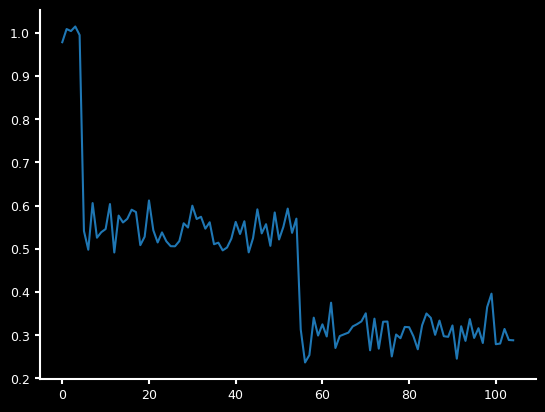

In [562]:
#plt.plot(full_data_flat_in_brain[21_800])
plt.plot(full_data_flat_in_brain[24_800])
#plt.plot(full_data_flat_in_brain[70_000])

In [563]:
# x_o = full_data_flat_in_brain[21_800]
x_o = full_data_flat_in_brain[24_800]
#x_o = full_data_flat_in_brain[70_000]

In [564]:
pred_mask = jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(jax.random.split(jax.random.key(0), 256), acq.bvals, acq.bvecs, x_o, jnp.array([0.1]))
pred_log_prob = jax.vmap(model.log_prob_mask, in_axes=(0,None,None, None, None))(pred_mask, acq.bvals, acq.bvecs, x_o, jnp.array([0.1]))

In [565]:
pred_mask.mean(0)

Array([1.   , 0.668, 0.598, 0.277, 1.   ], dtype=float32)

In [566]:
pred_mask[pred_log_prob.argmax()]

Array([ True,  True,  True, False,  True], dtype=bool)

In [567]:
thetas_post = jax.vmap(partial(model.sample_theta, num_steps=128, max_noise=80, model_mask=jnp.ones(5, dtype=jnp.bool)), in_axes=(0,None,None, None))(jax.random.split(jax.random.key(0), 4096), acq.bvals, acq.bvecs, x_o)

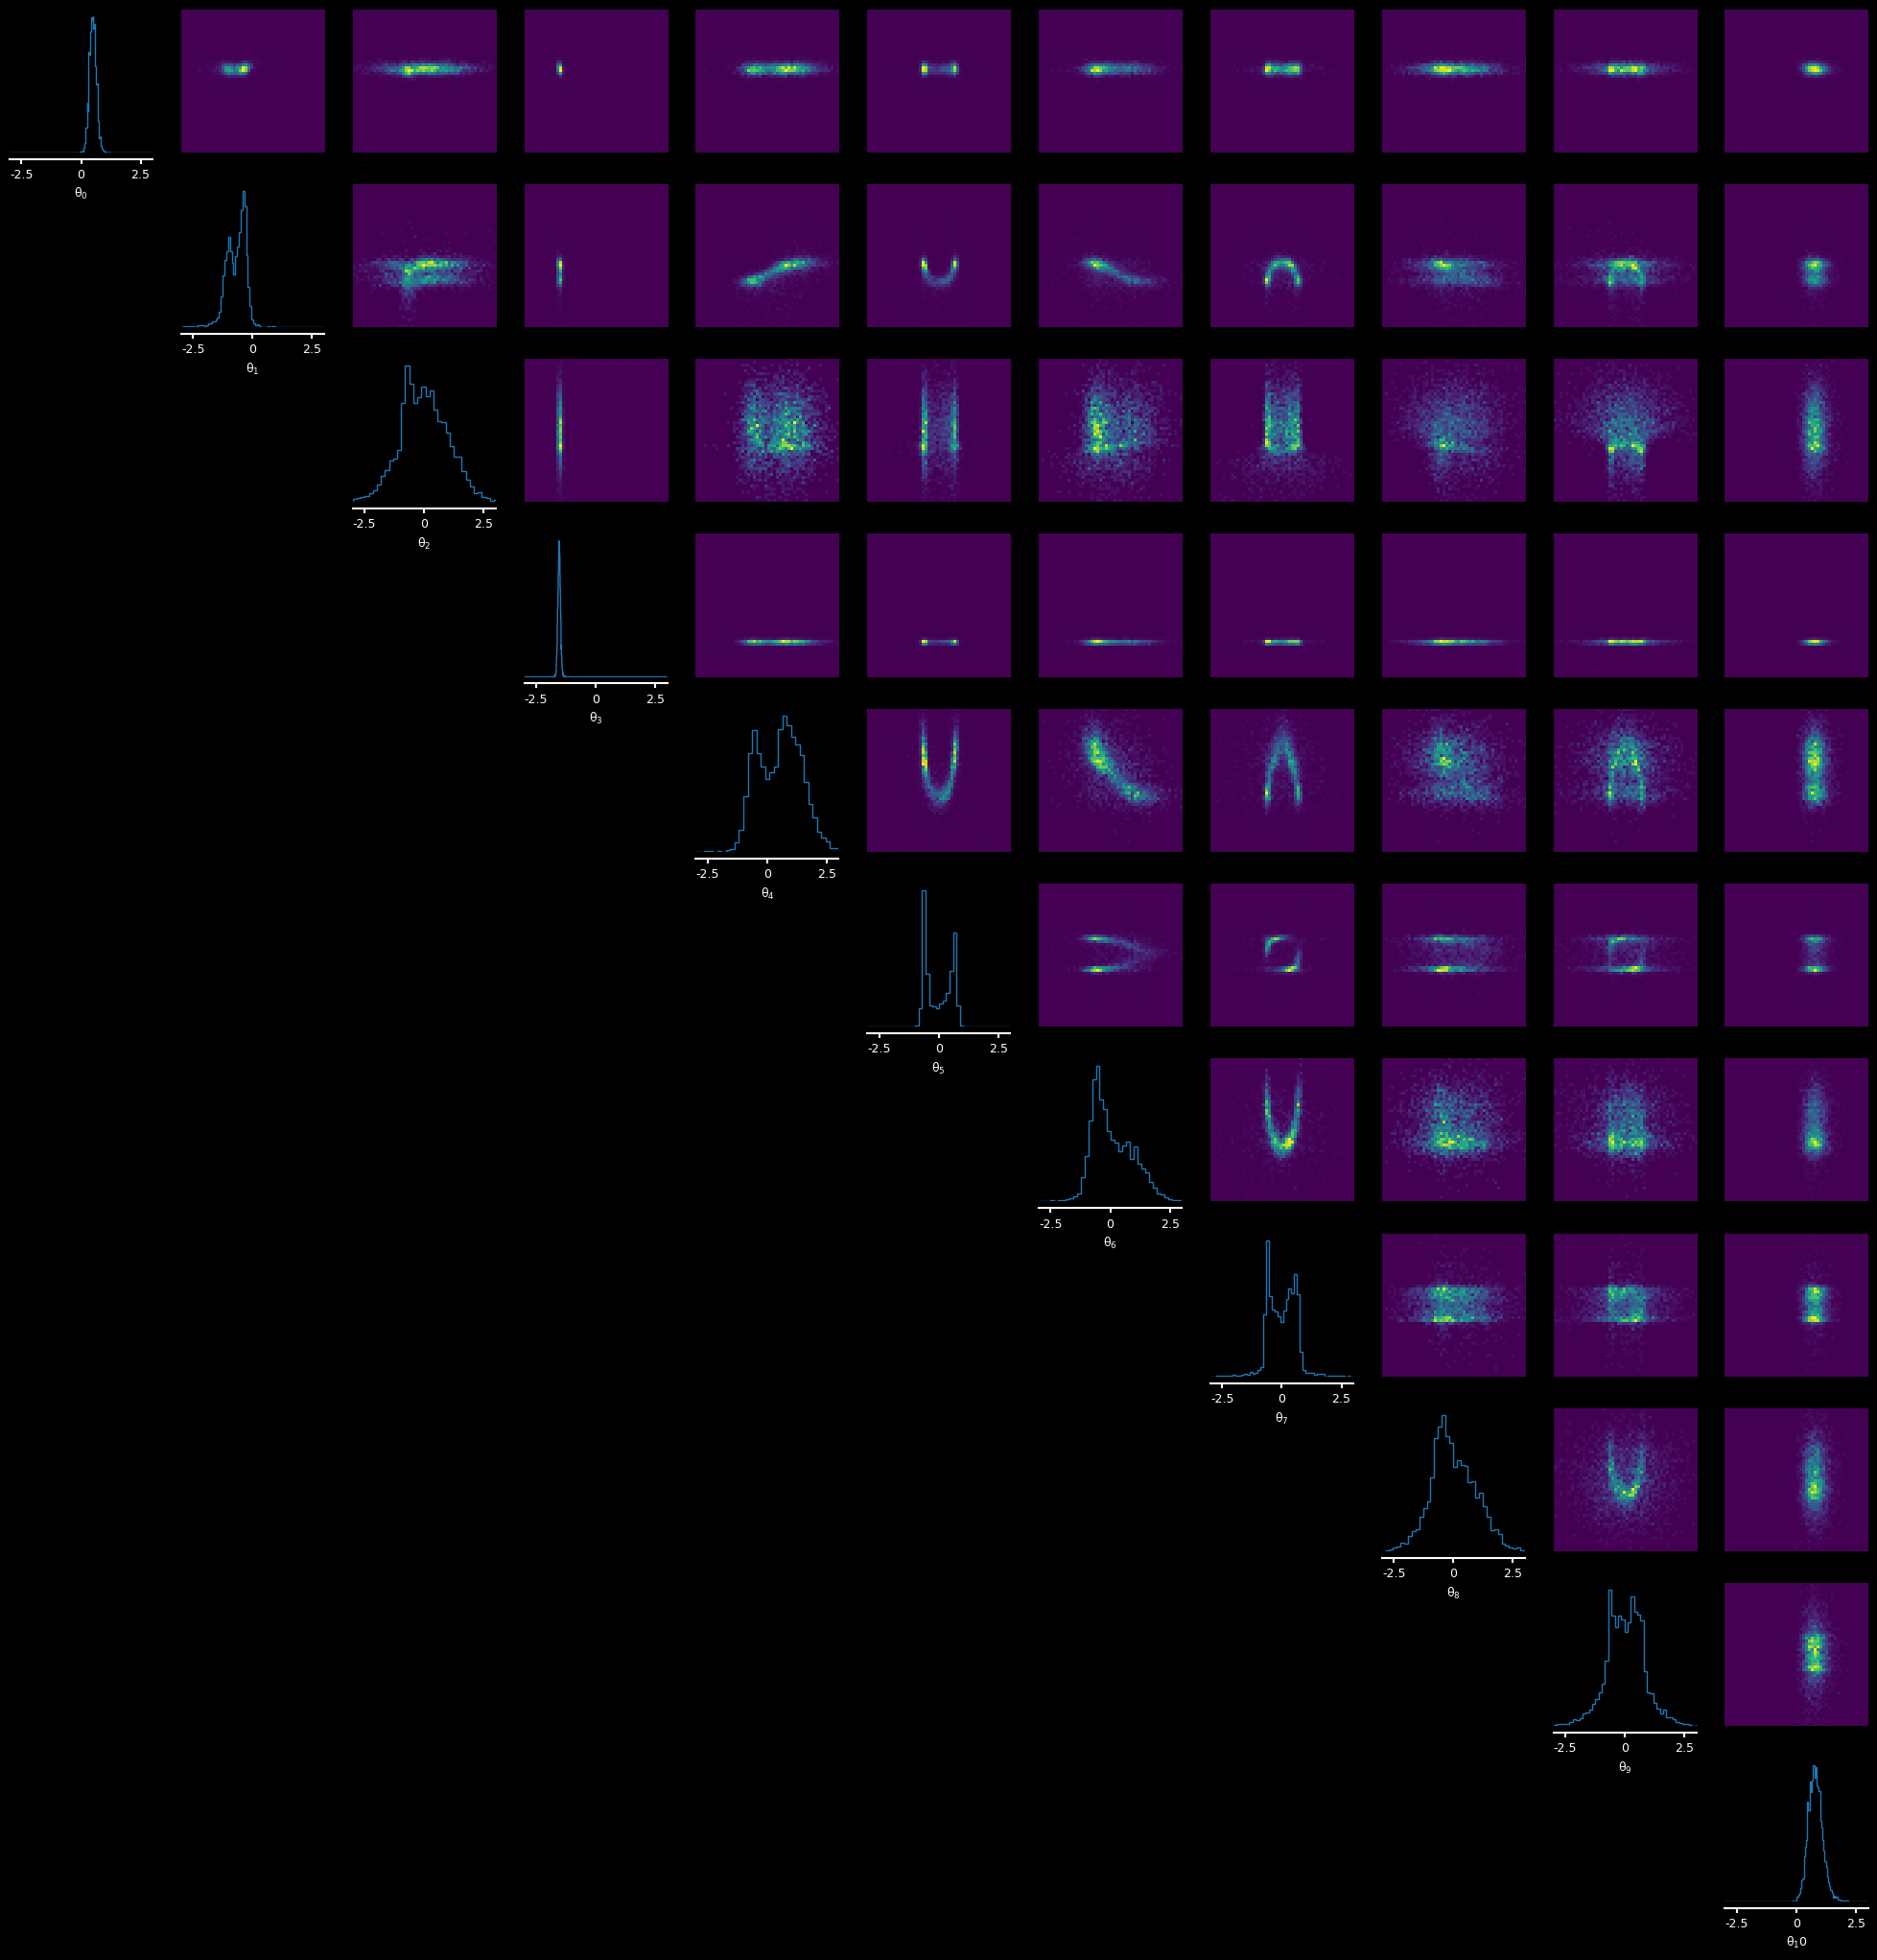

In [568]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(thetas_post, limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [574]:
def posterior_pred(theta,rng):
    return sim_type.from_theta(theta, model_mask=jnp.ones(5, dtype=jnp.bool)).signal(acq, rng=rng)

def log_likelihood_fn(theta):
    simulator = sim_type.from_theta(theta, model_mask=jnp.ones(5, dtype=jnp.bool))
    ll = simulator.log_likelihood(acquisition_scheme(acq.bvals, acq.bvecs), x_o)
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum(-1)

@jax.jit
def smc(thetas):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.005, num_integration_steps=5, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic

    smc = tempered_smc(log_prior_fn, log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 2)
    state = smc.init(thetas)
    state =state._replace(lmbda=0.99)

    def step(state, rng):
        state, i = state
        lmbda = 0.99 + (i+1)*0.01/5
        new_state, info = smc.step(rng, state, lmbda)
        ess = 1/jnp.sum(new_state.weights**2)
        acc_rate = info.update_info.acceptance_rate
        jax.debug.print("ESS: {ess}, acc_rate: {acc_rate}", ess=ess, acc_rate=acc_rate.mean())
        return (new_state, i+1), info

    rng_keys = jax.random.split(jax.random.key(0), 5)
    final_state, _ = jax.lax.scan(step, (state, 0), rng_keys)
    return final_state[0].particles


In [575]:
particles =smc(thetas_post)

ESS: 4019.45849609375, acc_rate: 0.9614060521125793
ESS: 4061.537109375, acc_rate: 0.9442853331565857
ESS: 4076.1416015625, acc_rate: 0.9337802529335022
ESS: 4083.85888671875, acc_rate: 0.9226276278495789
ESS: 4087.699462890625, acc_rate: 0.9226599335670471


Text(0, 0.5, 'MRI Signal')

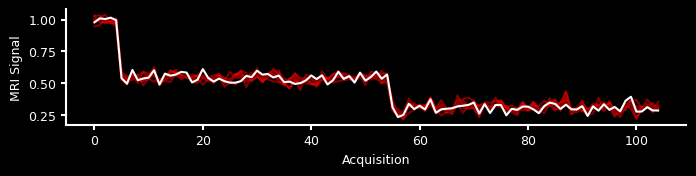

In [576]:

posterior_preds = jax.vmap(posterior_pred)(particles, jax.random.split(jax.random.key(0), 4096))


fig = plt.figure(figsize=(8, 1.5))

_ = plt.plot(posterior_preds[:5].T, label="posterior pred", color="red", alpha=0.5)
_ = plt.plot(posterior_preds.mean(0).T, label="posterior pred mean", color="darkred", linewidth=2)
_ = plt.plot(x_o, label="data", color="white")
plt.xlabel("Acquisition")
plt.ylabel("MRI Signal")

# fig.savefig(f"../figures/posterior_pred_idx={idx}.svg")
# fig.savefig(f"../figures/posterior_pred_idx={idx}.png")

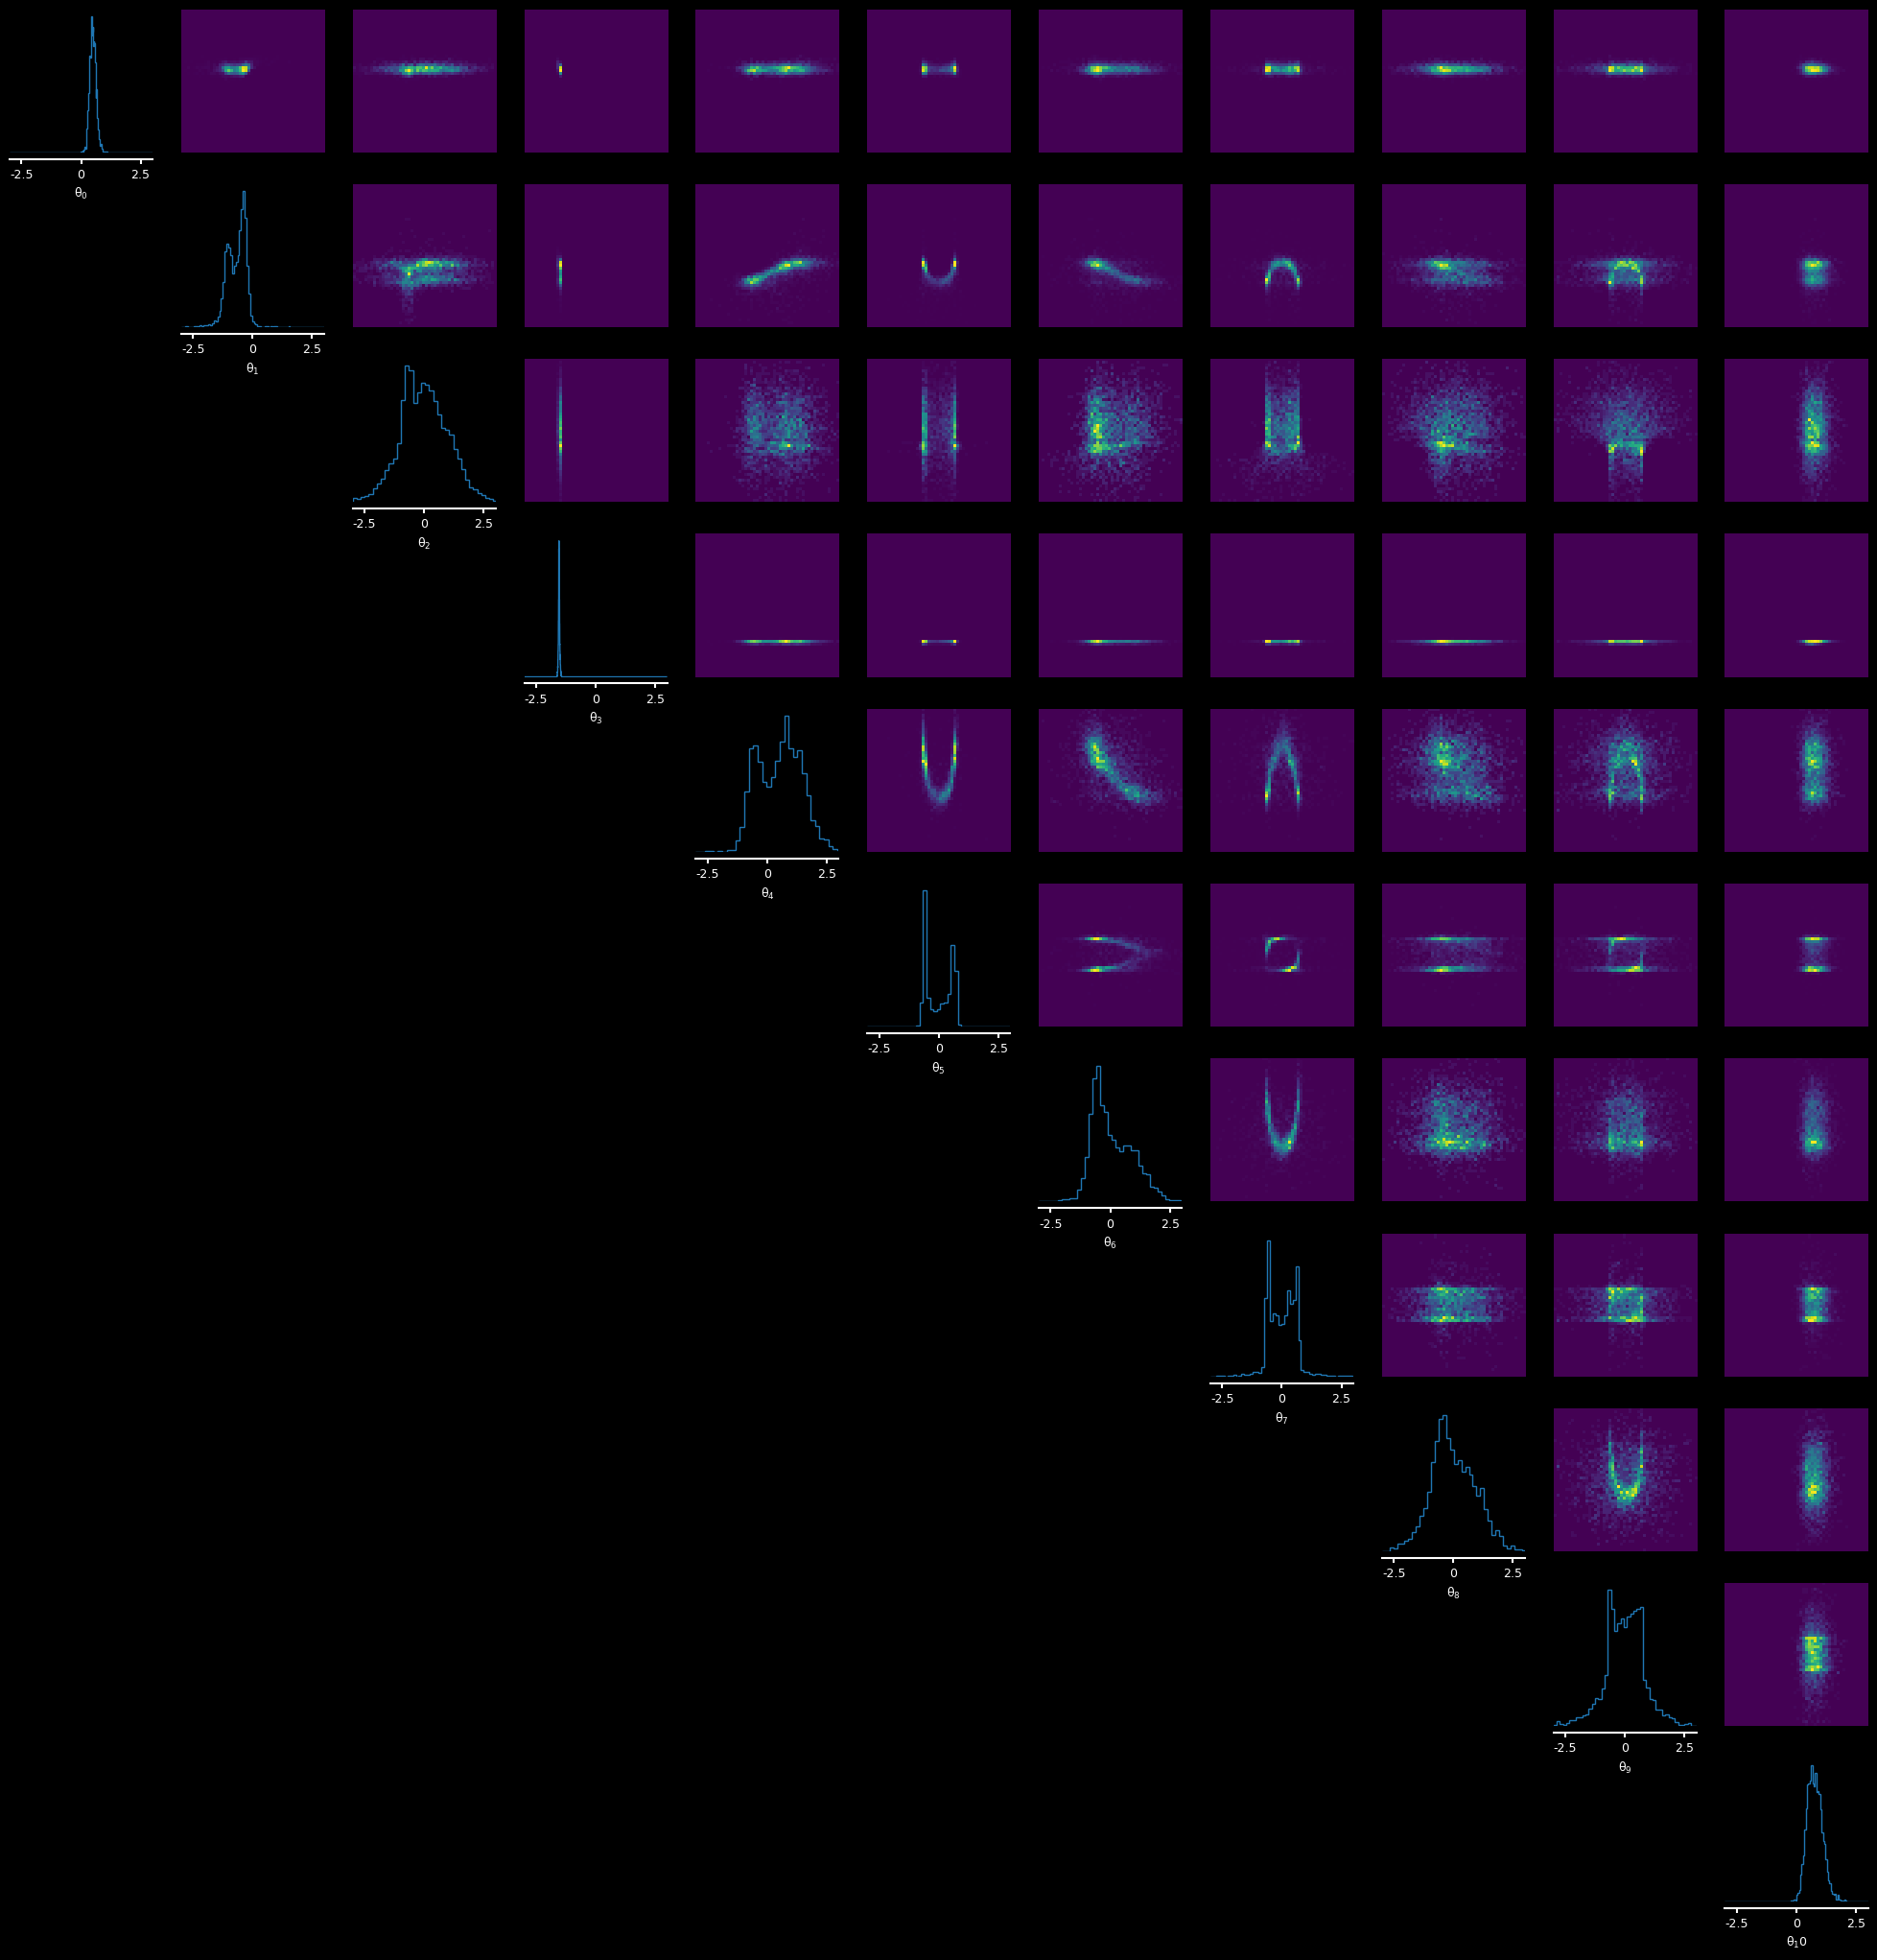

In [578]:
import sbi
from sbi.analysis.plot import pairplot

_ = pairplot(particles, limits=[[-3,3]*100], labels=[f'$\\theta_{i}$' for i in range(100)], figsize=(25, 25))

In [83]:
model_mask = jnp.array([True, True, True, True, True], dtype=jnp.bool)

def log_likelihood_fn(theta, mask, acq, x):
    simulator = sim_type.from_theta(theta, model_mask=mask)
    ll = simulator.log_likelihood(acq, x)
    return ll

def log_prior_fn(theta):
    return jax.scipy.stats.norm.logpdf(theta, 0, 1).sum()

def posterior_pred(theta, rng):
    return sim_type.from_theta(theta, model_mask=model_mask).signal(acq, rng=rng)

def smc(rng,thetas,model_mask, acq, x_o):
    hmc_kernel = hmc.build_kernel()
    hmc_kernel = partial(hmc_kernel, step_size=0.015, num_integration_steps=5, inverse_mass_matrix=jnp.ones(thetas.shape[1]))

    resampling_fn = systematic
    _log_likelihood_fn = partial(log_likelihood_fn, mask=model_mask, acq=acq, x=x_o)
    smc = tempered_smc(log_prior_fn, _log_likelihood_fn, hmc_kernel, hmc.init, {}, resampling_fn, 1)
    state = smc.init(thetas)
    state =state._replace(lmbda=1.)

    def step(state, rng):
        new_state, info = smc.step(rng, state, 1.)
        return new_state, info

    rng_keys = jax.random.split(rng, 10)
    final_state, _ = jax.lax.scan(step, state, rng_keys)
    return final_state.particles, final_state.weights


def sample_mcmc_correct(key, x):
    key, subkey = jax.random.split(key)
    K = 50
    propose_fn = partial(model.sample_theta, num_steps=32, max_noise=80)
    key_k = jax.random.split(key, K)
    theta = jax.vmap(propose_fn, in_axes=(0,None,None,None, None))(key_k, acq.bvals, acq.bvecs, x,model_mask)
    theta_corr, weights = smc(subkey, theta, model_mask, acq, x)
    return theta_corr, weights

sample_theta_per_x = jax.jit(jax.vmap(sample_mcmc_correct))

In [200]:
thetas_corr, weights = sample_theta_per_x(jax.random.split(jax.random.key(0), 30000), full_data_flat_in_brain[1000:31000])
ess = jnp.mean(1/jnp.sum(weights**2, axis=-1) / 50)
print(ess)


Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>


2025-05-08 11:02:53.862847: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 21.02GiB (22568184094 bytes) by rematerialization; only reduced to 37.55GiB (40320000000 bytes), down from 37.55GiB (40320000000 bytes) originally
2025-05-08 11:02:54.153744: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 21.02GiB (22568184094 bytes) by rematerialization; only reduced to 37.55GiB (40320000000 bytes), down from 37.55GiB (40320000000 bytes) originally
2025-05-08 11:02:54.160501: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 21.02GiB (22568184094 bytes) by rematerialization; only reduced to 37.55GiB (40320000000 bytes), down from 37.55GiB (40320000000 bytes) originally
2025-05-08 11:02:54.228204: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 21.02GiB (225681840

XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 40320000000 bytes.

In [186]:
thetas_corr.shape

(20000, 50, 11)

In [194]:
xs_pred = jax.vmap(jax.vmap(posterior_pred, in_axes=(0,None)))(thetas_corr, jax.random.split(jax.random.key(0), 20000))

In [195]:
xs_pred

(20000, 50, 105)

In [197]:
(xs_pred.mean(1) - full_data_flat_in_brain[1000:21000]).mean(0)

Array([-0.021, -0.008,  0.011,  0.007,  0.014, -0.021, -0.015, -0.017,
       -0.013, -0.016, -0.012, -0.01 , -0.016, -0.018, -0.011, -0.018,
       -0.013, -0.012, -0.013, -0.008, -0.009, -0.011, -0.011, -0.013,
       -0.015, -0.01 , -0.018, -0.015, -0.014, -0.013, -0.014, -0.018,
       -0.011, -0.01 , -0.005, -0.01 , -0.014, -0.006, -0.012, -0.011,
       -0.013, -0.01 , -0.011, -0.007, -0.012, -0.01 , -0.007, -0.009,
       -0.009, -0.011, -0.011, -0.014, -0.01 , -0.01 , -0.017, -0.027,
       -0.031, -0.033, -0.032, -0.032, -0.031, -0.027, -0.028, -0.034,
       -0.028, -0.027, -0.028, -0.031, -0.028, -0.029, -0.031, -0.028,
       -0.03 , -0.032, -0.029, -0.027, -0.028, -0.027, -0.027, -0.025,
       -0.029, -0.031, -0.031, -0.031, -0.032, -0.027, -0.03 , -0.028,
       -0.026, -0.025, -0.023, -0.026, -0.026, -0.031, -0.028, -0.031,
       -0.027, -0.029, -0.029, -0.025, -0.027, -0.024, -0.029, -0.027,
       -0.023], dtype=float32)

In [181]:
thetas_corr.sum()

Array(nan, dtype=float32)

In [198]:

#sample_theta_per_x = jax.jit(jax.vmap(lambda k, x: model.sample_theta(k, acq.bvals, acq.bvecs, x, model_mask, num_steps=64, max_noise=40), in_axes=(0,0)))

thetas = []
batch_size = 20_000
key = jax.random.key(0)
thetas_full = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    #batch_thetas, ess = sample_theta_per_x(batch_keys, batch_data)
    batch_thetas = sample_theta_per_x(batch_keys, batch_data)
    batch_thetas = np.array(batch_thetas)
    thetas_full.append(batch_thetas)
    #print(ess.mean())
thetas_full = np.concatenate(thetas_full, axis=0)


Batch 0
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>
Traced<ShapedArray(bool[3])>with<DynamicJaxprTrace>


KeyboardInterrupt: 

In [530]:
# Sample masks whole brain

def sample_mask_per_x(key, x):
    keys = jax.random.split(key, 500)
    return jax.vmap(model.sample_mask, in_axes=(0,None,None, None, None))(keys, acq.bvals, acq.bvecs, x, jnp.array([0.1]))

sample_mask_per_x = jax.jit(jax.vmap(sample_mask_per_x, in_axes=(0,0)))


In [531]:
jax.clear_caches()

In [532]:


batch_size = 1_000
key = jax.random.key(0)
masks_brain = []
key, subkey = jax.random.split(key)
for batch_start in range(0, full_data_flat_in_brain.shape[0], batch_size):
    print("Batch", batch_start)
    subkey, subkey_ = jax.random.split(subkey)
    batch_end = min(batch_start + batch_size, full_data_flat_in_brain.shape[0])
    batch_data = full_data_flat_in_brain[batch_start:batch_end]
    batch_keys = jax.random.split(subkey_, batch_data.shape[0])
    batch_masks = sample_mask_per_x(batch_keys, batch_data)
    batch_masks = np.array(batch_masks)
    masks_brain.append(batch_masks)
masks_brain = np.concatenate(masks_brain, axis=0)


Batch 0
Batch 1000
Batch 2000
Batch 3000
Batch 4000
Batch 5000
Batch 6000
Batch 7000
Batch 8000
Batch 9000
Batch 10000
Batch 11000
Batch 12000
Batch 13000
Batch 14000
Batch 15000
Batch 16000
Batch 17000
Batch 18000
Batch 19000
Batch 20000
Batch 21000
Batch 22000
Batch 23000
Batch 24000
Batch 25000
Batch 26000
Batch 27000
Batch 28000
Batch 29000
Batch 30000
Batch 31000
Batch 32000
Batch 33000
Batch 34000
Batch 35000
Batch 36000
Batch 37000
Batch 38000
Batch 39000
Batch 40000
Batch 41000
Batch 42000
Batch 43000
Batch 44000
Batch 45000
Batch 46000
Batch 47000
Batch 48000
Batch 49000
Batch 50000
Batch 51000
Batch 52000
Batch 53000
Batch 54000
Batch 55000
Batch 56000
Batch 57000
Batch 58000
Batch 59000
Batch 60000
Batch 61000
Batch 62000
Batch 63000
Batch 64000
Batch 65000
Batch 66000
Batch 67000
Batch 68000
Batch 69000
Batch 70000
Batch 71000
Batch 72000
Batch 73000
Batch 74000
Batch 75000
Batch 76000
Batch 77000
Batch 78000
Batch 79000
Batch 80000
Batch 81000
Batch 82000
Batch 83000
Batch

In [533]:
full_data_flat.shape

(778752, 105)

In [534]:
ball = jnp.array([True, False, False, False, True])
ball_stick1 = jnp.array([True, True, False, False, True])
ball_stick2 = jnp.array([True, False, True, False, True])
ball_stick3 = jnp.array([True, False, False, True, True])

ball_stick1_stick2 = jnp.array([True, True, True, False, True])
ball_stick1_stick3 = jnp.array([True, True, False, True, True])
ball_stick2_stick3 = jnp.array([True, False, True, True, True])

ball_stick1_stick2_stick3 = jnp.array([True, True, True, True, True])

p_ball = (masks_brain == ball).all(-1).mean(1)

p_ball_stick1 = (masks_brain == ball_stick1).all(-1).mean(1)
p_ball_stick2 = (masks_brain == ball_stick2).all(-1).mean(1)
p_ball_stick3 = (masks_brain == ball_stick3).all(-1).mean(1)

p_ball_stick1_stick2 = (masks_brain == ball_stick1_stick2).all(-1).mean(1)
p_ball_stick1_stick3 = (masks_brain == ball_stick1_stick3).all(-1).mean(1)
p_ball_stick2_stick3 = (masks_brain == ball_stick2_stick3).all(-1).mean(1)

p_ball_stick1_stick2_stick3 = (masks_brain == ball_stick1_stick2_stick3).all(-1).mean(1)

p_sim_configs = jnp.stack([p_ball, p_ball_stick1, p_ball_stick2, p_ball_stick3, p_ball_stick1_stick2, p_ball_stick1_stick3, p_ball_stick2_stick3, p_ball_stick1_stick2_stick3], axis=-1)
p_sim_configs = p_sim_configs / (p_sim_configs.sum(-1, keepdims=True) + 1e-10)

In [582]:
p_sim_configs.mean(0)

Array([0.038, 0.045, 0.033, 0.04 , 0.152, 0.067, 0.056, 0.568], dtype=float32)

: 

In [536]:
best_model = p_sim_configs.argmax(1)

In [537]:
marginal_probs = masks_brain.mean(1)
full_brain_marginal_probs = np.zeros((full_data_flat.shape[0], 5))
full_brain_marginal_probs[brain_mask_flat.astype(np.bool),...] = marginal_probs
full_brain_marginal_probs = full_brain_marginal_probs.reshape(data_norm.shape[:-1] + (5,))

In [538]:
full_p_sim_configs = np.zeros((full_data_flat.shape[0], 8))
full_p_sim_configs[brain_mask_flat.astype(np.bool),...] = p_sim_configs
full_p_sim_configs = full_p_sim_configs.reshape(data_norm.shape[:-1] + (8,))

In [539]:
full_best_model = np.zeros(full_data_flat.shape[0])
full_best_model[brain_mask_flat.astype(np.bool)] = best_model
full_best_model = full_best_model.reshape(data_norm.shape[:-1])

In [540]:
p_sim_configs.shape

(227840, 8)

In [543]:
np.quantile(marginal_probs[...,3], (0.05, 0.5,0.95))

array([0.202, 0.892, 1.   ])

In [544]:
p_sim_1stick = p_sim_configs[...,1:4].sum(-1)
p_sim_2stick = p_sim_configs[...,4:7].sum(-1)
p_sim_3stick = p_sim_configs[...,7:8].sum(-1)
p_stick_configs = jnp.stack([p_sim_1stick, p_sim_2stick, p_sim_3stick], axis=-1)
full_p_stick_configs = np.zeros((full_data_flat.shape[0], 3))
full_p_stick_configs[brain_mask_flat.astype(np.bool),...] = p_stick_configs
full_p_stick_configs = full_p_stick_configs.reshape(data_norm.shape[:-1] + (3,))


In [581]:
p_stick_configs.mean(0) / p_stick_configs.mean(0).sum()

Array([0.123, 0.286, 0.591], dtype=float32)

<OrthoSlicer3D: (104, 104, 72)>

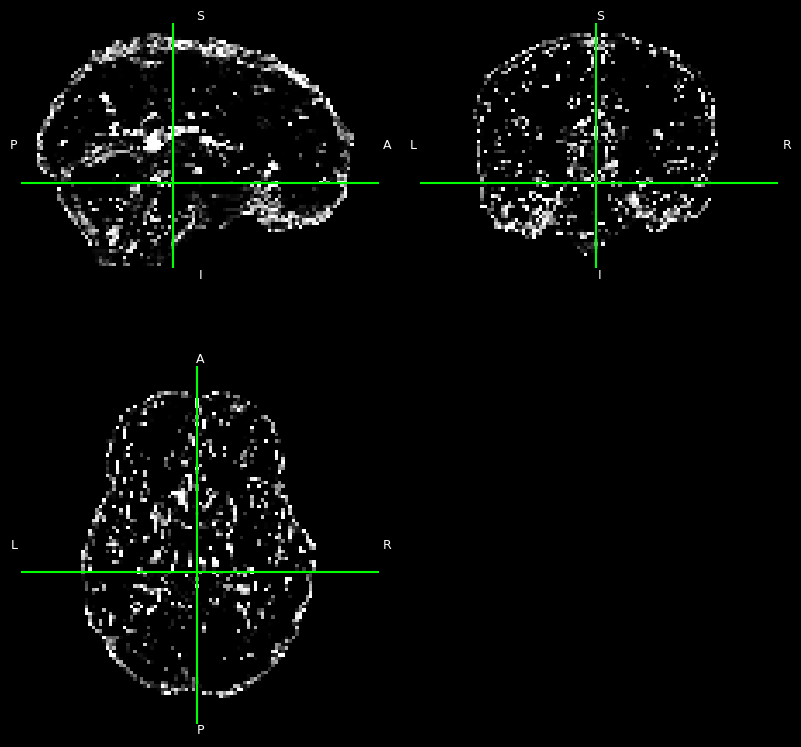

In [555]:
%matplotlib inline
import nibabel as nb
nb.Nifti1Image(full_p_stick_configs[...,0], affine).orthoview()